In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/Range_prediction_data.csv'

In [ ]:
data = pd.read_csv(file_path)
data


,Voltage,Current,Power Consumed (W),Battery Capacity (W),Driving Range (W)
0,11.805,40.060976,4.496951,995.503049,348.426067
1,11.749,45.548780,5.045732,990.457317,346.660061
2,11.693,53.536585,15.015244,975.442073,341.404726
3,11.637,52.500000,4.618902,970.823171,339.788110
4,11.581,-10.731707,3.475610,967.347561,338.571646
...,...,...,...,...,...
146,3.629,50.792683,4.573171,350.167683,122.558689
147,3.573,44.390244,5.350610,344.817073,120.685976
148,3.517,32.804878,3.216463,341.600610,119.560213
149,3.461,-110.914634,2.621951,338.978659,118.642530


In [ ]:
print(data.shape)

data = data.drop_duplicates()
print(data.shape)

data.isnull().sum()

(151, 5)
(151, 5)


Voltage                 0
Current                 0
Power Consumed (W)      0
Battery Capacity (W)    0
Driving Range (W)       0
dtype: int64

In [ ]:
data = np.array(data)
X = data[:,:-1]
Y = data[:,-1]
#print(X)
#print(Y)

In [ ]:
from sklearn.metrics import mean_squared_error as mse

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# Load the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Assuming you have features like Voltage, Current, and Power Consumed
# X represents the features, y represents the target variable (Driving Range)
X = df[['Voltage', 'Current', 'Power Consumed (W)']]  # Features
y = df['Driving Range (W)']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the driving range for the test set
y_pred = model.predict(X_test)

# Calculate the coefficient of determination (R^2) to evaluate the model
r_squared = model.score(X_test, y_test)
print(f'Coefficient of determination (R^2): {r_squared}')

# Display predicted values and actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)


Coefficient of determination (R^2): 0.9982644671718596
         Actual   Predicted
114  170.080793  169.384048
62   246.467226  247.810231
33   288.733994  291.624840
107  179.993902  179.927056
7    334.148628  330.848936
100  192.435976  190.521952
40   282.491616  281.518016
86   213.633384  211.798461
76   228.791159  226.698041
71   236.175305  234.291387
134  137.294970  139.239250
51   266.613567  264.557712
73   233.971799  231.401463
54   259.282774  258.794512
63   246.355183  246.855024
37   285.756860  285.811302
78   223.327744  223.745818
90   208.650152  205.835177
45   273.784299  273.430442
16   315.010671  316.428843
121  157.478659  158.725039
66   242.999238  241.786381
24   300.012957  305.319539
8    332.297256  329.307075
126  148.717988  151.237819
22   302.899390  308.182194
44   275.657012  275.034704
97   197.456555  194.815509
93   203.368140  201.152252
26   298.439024  302.681618
137  135.331555  135.111513


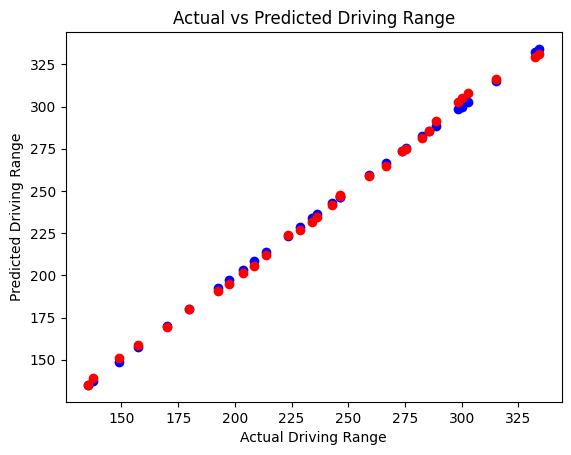

In [ ]:
import matplotlib.pyplot as plt

# Plot graph for actual vs predicted
plt.scatter(y_test, y_test, color='blue', label='Actual')  # Plotting y_test against itself to set up the axis
plt.scatter(y_test, y_pred, color='red', label='Predicted')
plt.xlabel('Actual Driving Range')
plt.ylabel('Predicted Driving Range')
plt.title('Actual vs Predicted Driving Range')
plt.show()



In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Calculate RMSE
rmse = sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Square Error (RMSE): {rmse}')


Root Mean Square Error (RMSE): 2.3244192070993575


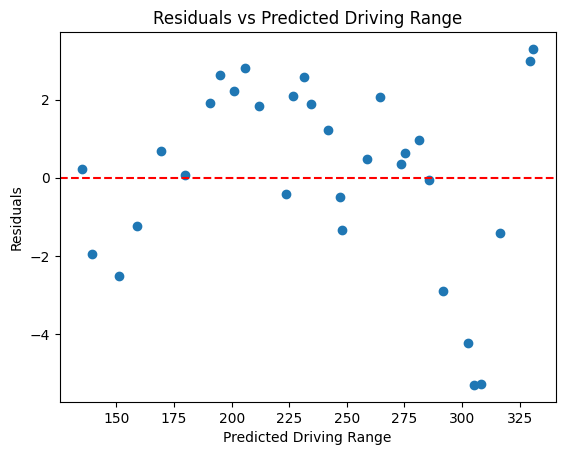

In [ ]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Driving Range')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Driving Range')
plt.axhline(y=0, color='r', linestyle='--')  # Add horizontal line at y=0 for reference
plt.show()


Linear Regression
mean_squared_error :  6.0534862749093685


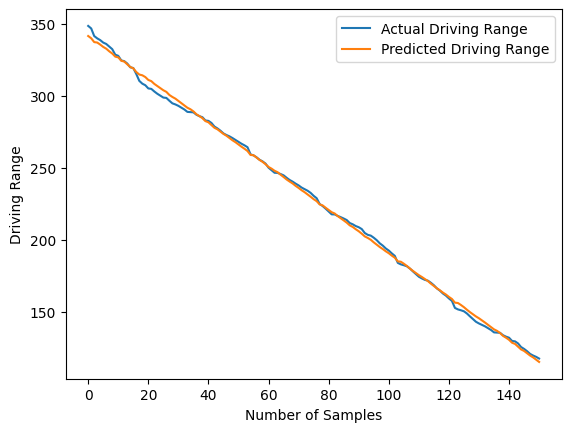

In [ ]:
# Multiple Linear Regression

from sklearn.linear_model import LinearRegression
Lr = LinearRegression()
Lr.fit(X,Y)

Y_pred = Lr.predict(X)

plt.plot(Y)
plt.plot(Y_pred)
plt.xlabel('Number of Samples')
plt.ylabel('Driving Range')
plt.legend(['Actual Driving Range','Predicted Driving Range'])

mse_Lr = mse(Y,Y_pred)
print('Linear Regression\nmean_squared_error : ',mse_Lr)

Random Forest
mean_squared_error :  0.7332323551755844


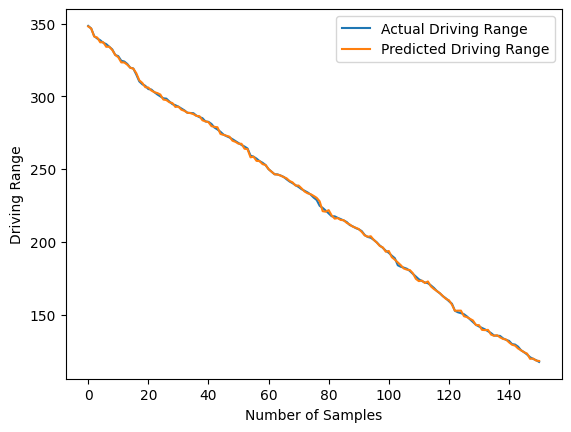

In [ ]:
# Random Forest Regresion

from sklearn.ensemble import RandomForestRegressor
random_forest = RandomForestRegressor(n_estimators = 5,random_state = 0)
random_forest.fit(X,Y)

Y_pred = random_forest.predict(X)

plt.plot(Y)
plt.plot(Y_pred)
plt.xlabel('Number of Samples')
plt.ylabel('Driving Range')
plt.legend(['Actual Driving Range','Predicted Driving Range'])

mse_random_forest = mse(Y,Y_pred)
print('Random Forest\nmean_squared_error : ', mse_random_forest)

Polynomial Regression
mean_squared_error :  5.351168921823535


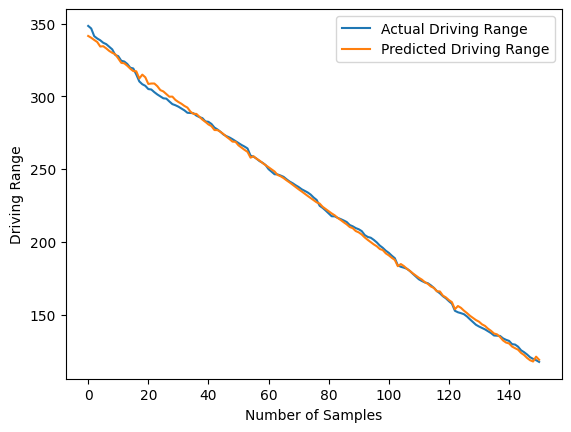

In [ ]:
# Polynomial Regression

from sklearn.preprocessing import PolynomialFeatures
poly_ft = PolynomialFeatures(degree = 2)

X_poly = poly_ft.fit_transform(X)

poly = LinearRegression()
poly.fit(X_poly,Y)

Y_pred = poly.predict(X_poly)

plt.plot(Y)
plt.plot(Y_pred)
plt.xlabel('Number of Samples')
plt.ylabel('Driving Range')
plt.legend(['Actual Driving Range','Predicted Driving Range'])

mse_poly = mse(Y,Y_pred)
print('Polynomial Regression\nmean_squared_error : ', mse_poly)

Support Vector Machine
mean_squared_error :  4243.708683748976


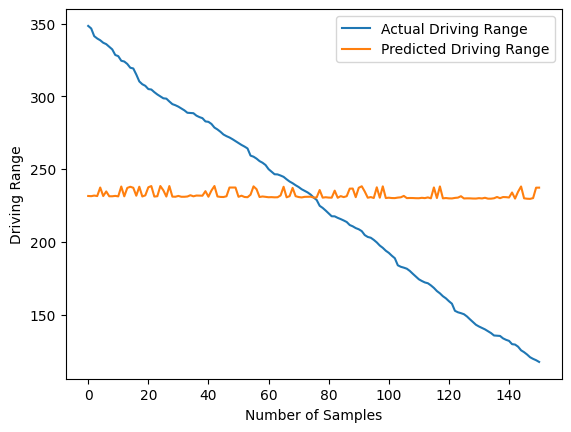

In [ ]:
# Support Vector Regression

from sklearn.svm import SVR
svr = SVR(kernel = 'rbf')
svr.fit(X, Y)

Y_pred = svr.predict(X)

plt.plot(Y)
plt.plot(Y_pred)
plt.xlabel('Number of Samples')
plt.ylabel('Driving Range')
plt.legend(['Actual Driving Range','Predicted Driving Range'])

mse_svr = mse(Y,Y_pred)
print('Support Vector Machine\nmean_squared_error : ', mse_svr)

Mean Sqaured Error : 
 [6.0534862749093685, 0.7332323551755844, 5.351168921823535, 4243.708683748976]


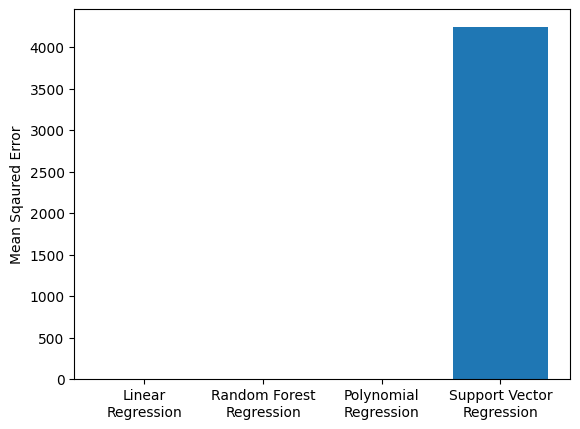

In [ ]:
labels = ['Linear\nRegression', 'Random Forest\nRegression', 'Polynomial\nRegression', 'Support Vector\nRegression']
plt.bar( labels, [mse_Lr, mse_random_forest, mse_poly, mse_svr])
plt.ylabel('Mean Sqaured Error')
print('Mean Sqaured Error : \n',[mse_Lr, mse_random_forest, mse_poly, mse_svr])

In [ ]:
# Sample Test Input

X_in = [8.56, 50, 4.3]

print('Linear Regression         :', Lr.predict([X_in])[0] ,'KM')
print('Random Forest Regression  :', random_forest.predict([X_in])[0] ,'KM')
print('Polynomial Regression     :', poly.predict(poly_ft.transform([X_in]))[0] ,'KM')
print('Support Vector Regression :', svr.predict(X)[0] ,'KM')

Linear Regression         : 254.0271478687665 KM
Random Forest Regression  : 255.0496951229937 KM
Polynomial Regression     : 254.47656534090953 KM
Support Vector Regression : 231.52643370261333 KM


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
